

# <p style="background-color:#808080;font-family:newtimeroman;color:#000000;font-size:150%;text-align:center;border-radius:40px 40px;">Brain Tumor Detection--- Keras/Pytorch</p>




# <p style="background-color:#808080;font-family:newtimeroman;color:#000000;font-size:150%;text-align:center;border-radius:40px 40px;">Importing Modules</p>

In [4]:
import seaborn as sns
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D
from tensorflow.keras.optimizers import Adam
import torch
import glob
import torch.nn as nn
from torchvision.transforms import transforms
from torch.utils.data import DataLoader
from torch.optim import Adam
from torch.autograd import Variable
import torchvision
import pathlib
from skimage.io import imread
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from tqdm import tqdm
from torch.nn import Linear, ReLU, CrossEntropyLoss, Sequential, Conv2d, MaxPool2d, Module, Softmax, BatchNorm2d, Dropout
from torch.optim import SGD
import warnings
warnings.filterwarnings("ignore")



# <p style="background-color:#808080;font-family:newtimeroman;color:#000000;font-size:150%;text-align:center;border-radius:40px 40px;">Building Model Using Keras</p>



# <p style="background-color:#808080;font-family:newtimeroman;color:#000000;font-size:150%;text-align:center;border-radius:40px 40px;">Preparing The Data For Keras Model</p>

In [5]:
train_img = []
train_labels = []

test_img = []
test_labels = []

path_train = (r"C:\Users\admin\Desktop\PFE\dataset\archive\Training")
path_test = (r"C:\Users\admin\Desktop\PFE\dataset\archive\Testing")
img_size= 128

for i in os.listdir(path_train):
    for j in os.listdir(os.path.join(path_train, i)):
        try:
            img = cv2.imread(os.path.join(path_train, i, j))
            if img is not None and len(img.shape) == 3 and img.shape[-1] == 3:
                train_img.append (cv2.resize(img, (img_size,img_size)) / 255.0) 
                train_labels.append(i)
        except:
            pass
        
for i in os.listdir(path_test):
    for j in os.listdir(os.path.join(path_test, i)):
        try:
            img = cv2.imread(os.path.join(path_test, i, j))
            if img is not None and len(img.shape) == 3 and img.shape[-1] == 3:
                test_img.append (cv2.resize(img, (img_size,img_size)) / 255.0) 
                test_labels.append(i)
        except:
            pass
        
train_img = np.array(train_img, dtype=np.float32)
test_img = np.array(test_img, dtype=np.float32)

In [6]:
print("Shape of train: ", np.array(train_img).shape, " and shape of test: ", np.array(test_img).shape)

Shape of train:  (2870, 128, 128, 3)  and shape of test:  (394, 128, 128, 3)




# <p style="background-color:#808080;font-family:newtimeroman;color:#000000;font-size:150%;text-align:center;border-radius:40px 40px;">Augmenting The Data</p>

In [7]:

img_datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True)

img_datagen.fit(train_img)
img_datagen.fit(test_img)

In [8]:
train_x, val_x, train_y, val_y = train_test_split(np.array(train_img), np.array(train_labels), test_size = 0.1)
train_x.shape, train_y.shape, val_x.shape, val_y.shape


((2583, 128, 128, 3), (2583,), (287, 128, 128, 3), (287,))



# <p style="background-color:#808080;font-family:newtimeroman;color:#000000;font-size:150%;text-align:center;border-radius:40px 40px;">Some Visualizations</p>

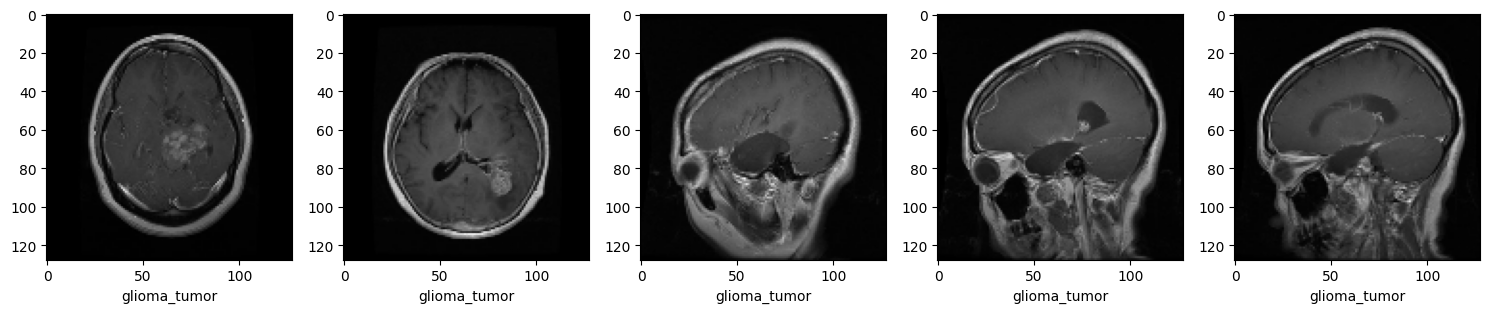

In [9]:
plt.figure(figsize = (15,15));
for i,j in enumerate(train_img):
    if i<5:
        plt.subplot(1,5,i+1)
        plt.imshow(j);
        plt.xlabel(train_labels[i]);
        plt.tight_layout()
    else:
        break

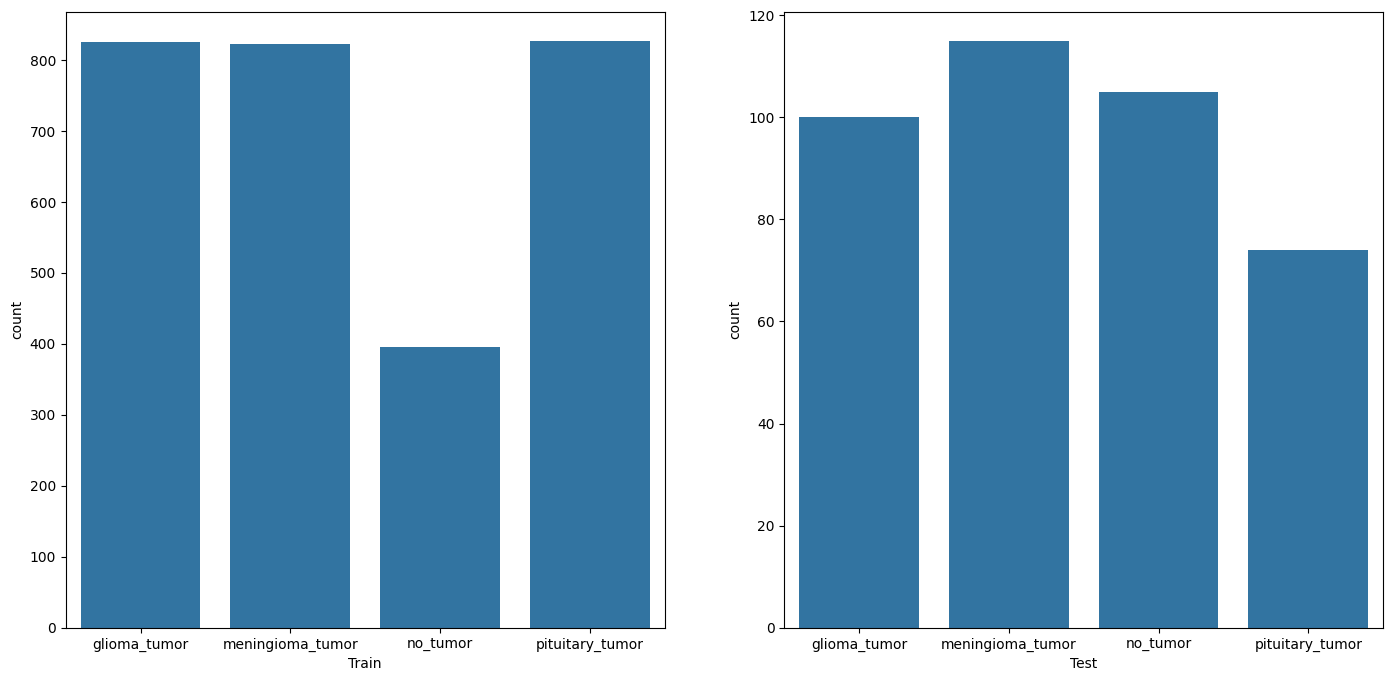

In [8]:
plt.figure(figsize = (17,8));
lis = ['Train', 'Test']
for i,j in enumerate([train_labels, test_labels]):
    plt.subplot(1,2, i+1);
    sns.countplot(x = j);
    plt.xlabel(lis[i])


In [9]:
model = tf.keras.Sequential(
        [
          tf.keras.layers.Conv2D(kernel_size=(5,5) ,filters=32, activation='relu', padding='same'),
          tf.keras.layers.MaxPool2D(pool_size=(2,2)),

          tf.keras.layers.Conv2D(kernel_size=(3,3),filters=32, activation='relu', padding='same'),
          tf.keras.layers.MaxPool2D(pool_size=(2,2)),

          tf.keras.layers.Conv2D(kernel_size=(3,3) ,filters=32, activation='relu', padding='same'),
          tf.keras.layers.MaxPool2D(pool_size=(2,2)),

          tf.keras.layers.Conv2D(kernel_size=(3,3) ,filters=64, activation='relu', padding='same'),
          tf.keras.layers.MaxPool2D(pool_size=(2,2)),

          tf.keras.layers.Flatten(),
          tf.keras.layers.Dense(128, activation='relu'),
          tf.keras.layers.Dropout(rate=0.5),
          tf.keras.layers.Dense(4, activation='softmax')
  ])
model.compile(optimizer=tf.keras.optimizers.Adam(),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [10]:
history = model.fit(train_x.astype('float32'), pd.get_dummies(train_y), validation_data=(val_x.astype('float32'), pd.get_dummies(val_y)), epochs=5, verbose=1, batch_size=16)

Epoch 1/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 100s 536ms/step - accuracy: 0.5110 - loss: 1.0750 - val_accuracy: 0.6132 - val_loss: 0.8061
Epoch 2/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 104s 301ms/step - accuracy: 0.6520 - loss: 0.7986 - val_accuracy: 0.7700 - val_loss: 0.5882
Epoch 3/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 53s 326ms/step - accuracy: 0.7309 - loss: 0.6297 - val_accuracy: 0.8258 - val_loss: 0.4669
Epoch 4/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 80s 314ms/step - accuracy: 0.8126 - loss: 0.4821 - val_accuracy: 0.8815 - val_loss: 0.3524
Epoch 5/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 80s 297ms/step - accuracy: 0.8366 - loss: 0.4063 - val_accuracy: 0.9024 - val_loss: 0.2695




## <p style="background-color:#808080;font-family:newtimeroman;color:#000000;font-size:150%;text-align:center;border-radius:40px 40px;">Key Notes</p>
> Adding padding here to preserve the image shape

> Adding maxpool layer to get those pixels which have the highest intensity. Reduces the image size by 2.

> Took filters of 7*7 as image size if 300 * 300 thus it would help it to learn better.
 
> Taken a dropout layer, to avoid overfitting.

 > The image from data generator is of type 'uint8', you need to type cast it to 'float32'.

In [11]:
model.layers[0].get_weights()[0].shape

(5, 5, 3, 32)



# <p style="background-color:#808080;font-family:newtimeroman;color:#000000;font-size:150%;text-align:center;border-radius:40px 40px;">Building The Model With Pytorch</p>


# <p style="background-color:#808080;font-family:newtimeroman;color:#000000;font-size:150%;text-align:center;border-radius:40px 40px;">Preparing The Data For Pytorch Model</p>

In [12]:
train_x, val_x, train_y, val_y = train_test_split(np.array(train_img), np.array(train_labels), test_size = 0.1)
train_x.shape, train_y.shape, val_x.shape, val_y.shape


((2583, 128, 128, 3), (2583,), (287, 128, 128, 3), (287,))

# <p style="background-color:#808080;font-family:newtimeroman;color:#000000;font-size:150%;text-align:center;border-radius:40px 40px;">Applying Data Transformations</p>

In [13]:
transforming_img = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),  
    transforms.Normalize([0.5,0.5,0.5], 
                        [0.5,0.5,0.5])
])

In [14]:
train_path = r'C:\Users\admin\Desktop\PFE\dataset\archive\Training'
test_path = r'C:\Users\admin\Desktop\PFE\dataset\archive\Testing'

train_loader=DataLoader(
    torchvision.datasets.ImageFolder(train_path,transform=transforming_img),
    batch_size=64, shuffle=True
)
test_loader=DataLoader(
    torchvision.datasets.ImageFolder(test_path,transform=transforming_img),
    batch_size=32, shuffle=True
)

In [15]:
root = pathlib.Path(train_path)
classes = sorted([j.name.split('/')[-1] for j in root.iterdir()])

print(f'The classes are: {classes}')

The classes are: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


In [16]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device


train_count=len(glob.glob(train_path+'/**/*.jpg'))
test_count=len(glob.glob(test_path+'/**/*.jpg'))

In [17]:
class ConvNet(nn.Module):
    def __init__(self,num_classes=4):
        super(ConvNet,self).__init__()
        
         
        self.conv1=nn.Conv2d(in_channels=3, out_channels=12, kernel_size=3, stride=1, padding=1)
        
        self.bn1=nn.BatchNorm2d(num_features=12)
        self.relu1=nn.ReLU()        
        self.pool=nn.MaxPool2d(kernel_size=2)
        self.conv2=nn.Conv2d(in_channels=12,out_channels=20,kernel_size=3,stride=1,padding=1)
        self.relu2=nn.ReLU()
        self.conv3=nn.Conv2d(in_channels=20,out_channels=32,kernel_size=3,stride=1,padding=1)
        self.bn3=nn.BatchNorm2d(num_features=32)
        self.relu3=nn.ReLU()
        self.fc=nn.Linear(in_features=64 * 64 * 32,out_features=num_classes)
        
        
        
        #Feed forwad function
        
    def forward(self,input):
        output=self.conv1(input)
        output=self.bn1(output)
        output=self.relu1(output)
        output=self.pool(output)
        output=self.conv2(output)
        output=self.relu2(output)
        output=self.conv3(output)
        output=self.bn3(output)
        output=self.relu3(output)            
        output=output.view(-1,64*64*32)
        output=self.fc(output)
            
        return output
    
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
   
model_pytorch=ConvNet(num_classes=4).to(device)

In [18]:
for i, (images,labels) in enumerate(train_loader):
        if torch.cuda.is_available():
            images=Variable(images.cuda())
            labels=Variable(labels.cuda())

In [19]:
images.shape

torch.Size([54, 3, 128, 128])

In [ ]:
#Optmizer and loss function
optimizer=Adam(model_pytorch.parameters(),lr=0.001,weight_decay=0.0001)
loss_function=nn.CrossEntropyLoss()



best_accuracy=0.0

for epoch in range(5):
    
    #Evaluation and training on training dataset
    model_pytorch.train()
    train_accuracy=0.0
    train_loss=0.0
    
    for i, (images,labels) in enumerate(train_loader):
        if torch.cuda.is_available():
            images=Variable(images.cuda())
            labels=Variable(labels.cuda())
            
        optimizer.zero_grad()
        
        outputs=model_pytorch(images)
        loss=loss_function(outputs,labels)
        loss.backward()
        optimizer.step()
        
        
        train_loss+= loss.cpu().data*images.size(0)
        _,prediction=torch.max(outputs.data,1)
        
        train_accuracy+=int(torch.sum(prediction==labels.data))
        
    train_accuracy=train_accuracy/train_count
    train_loss=train_loss/train_count
    
    
    # Evaluation on testing dataset
    model_pytorch.eval()
    
    test_accuracy=0.0
    for i, (images,labels) in enumerate(test_loader):
        if torch.cuda.is_available():
            images=Variable(images.cuda())
            labels=Variable(labels.cuda())
            
        outputs=model_pytorch(images)
        _,prediction=torch.max(outputs.data,1)
        test_accuracy+=int(torch.sum(prediction==labels.data))
    
    test_accuracy=test_accuracy/test_count
    
    
    print('Epoch: '+str(epoch)+' Train Loss: '+str(train_loss)+' Train Accuracy: '+str(train_accuracy)+' Test Accuracy: '+str(test_accuracy))
    
    if test_accuracy>best_accuracy:
        torch.save(model_pytorch.state_dict(),'best_checkpoint.model')
        best_accuracy=test_accuracy

Epoch: 0 Train Loss: tensor(7.1346) Train Accuracy: 0.5773519163763067 Test Accuracy: 0.4467005076142132
Epoch: 1 Train Loss: tensor(1.2308) Train Accuracy: 0.7686411149825784 Test Accuracy: 0.467005076142132
Epoch: 2 Train Loss: tensor(0.7290) Train Accuracy: 0.8331010452961672 Test Accuracy: 0.5050761421319797
Epoch: 3 Train Loss: tensor(0.5372) Train Accuracy: 0.8686411149825783 Test Accuracy: 0.6725888324873096
Epoch: 4 Train Loss: tensor(0.9642) Train Accuracy: 0.8177700348432055 Test Accuracy: 0.6421319796954315


: 



# <p style="background-color:#808080;font-family:newtimeroman;color:#000000;font-size:150%;text-align:center;border-radius:40px 40px;">Conclusion </p>
<h1>In this notebook, I tried to implement a standard CNN using both Keras and pytorch.</h1>